# Sales Forecasting Data Preparation

## Overview

Sales forecasting is one of the most important analytical tasks in retail businesses. Accurate forecasts help organizations optimize inventory, improve supply chain planning, allocate staff efficiently, and maximize revenue.

In this notebook, we prepare the cleaned retail transaction data for time series forecasting. Instead of training forecasting models directly, this notebook focuses on transforming transactional sales data into structured time series datasets suitable for forecasting algorithms.

The generated datasets will be used in the next notebook (**05_sales_forecasting_model.ipynb**) for model development and evaluation.

---

## Objectives

- Load the cleaned retail dataset.
- Validate data quality for forecasting.
- Aggregate transactional sales into daily revenue.
- Generate a continuous daily time series.
- Engineer forecasting features.
- Perform chronological train-test splitting.
- Save reusable forecasting datasets.
- Generate summary statistics and visualizations.

---

## Input

- `data/processed/retail_cleaned.csv`

---

## Outputs

- `data/processed/daily_sales.csv`
- `data/processed/daily_sales_features.csv`
- `data/processed/train_sales.csv`
- `data/processed/test_sales.csv`
- `reports/forecasting_dataset_summary.csv`
- Forecasting visualizations saved in `reports/figures/`

In [2]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot style
plt.style.use("ggplot")

print("=" * 60)
print("RetailPulse - Sales Forecasting Data Preparation")
print("=" * 60)

RetailPulse - Sales Forecasting Data Preparation


In [3]:
# ==========================================
# Project Paths and Directory Setup
# ==========================================

# Project root directory
PROJECT_ROOT = Path.cwd().parent

# Data directories
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

# Models directory
MODELS_DIR = PROJECT_ROOT / "models"

# Reports directories
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

# Create directories if they do not exist
for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MODELS_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Input dataset
INPUT_FILE = PROCESSED_DATA_DIR / "retail_cleaned.csv"

# Verify dataset availability
if not INPUT_FILE.exists():
    raise FileNotFoundError(
        f"Input dataset not found:\n{INPUT_FILE}\n\n"
        "Please complete Notebook 01 before continuing."
    )

print("=" * 60)
print("Project directories verified successfully.")
print(f"Input Dataset : {INPUT_FILE}")
print("=" * 60)

Project directories verified successfully.
Input Dataset : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\data\processed\retail_cleaned.csv


In [4]:
# ==========================================
# Load the Cleaned Retail Dataset
# ==========================================

# Load dataset
retail_df = pd.read_csv(INPUT_FILE)

print("=" * 60)
print("Dataset Loaded Successfully")
print("=" * 60)

print(f"Shape : {retail_df.shape}")

print("\nColumn Names")
print("-" * 60)
print(retail_df.columns.tolist())

print("\nData Types")
print("-" * 60)
print(retail_df.dtypes)

print("\nFirst Five Records")
print("-" * 60)
display(retail_df.head())

Dataset Loaded Successfully
Shape : (779425, 22)

Column Names
------------------------------------------------------------
['InvoiceID', 'StockCode', 'ProductDescription', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount', 'InvoiceYear', 'InvoiceQuarter', 'InvoiceMonth', 'MonthName', 'InvoiceWeek', 'InvoiceDay', 'DayName', 'InvoiceHour', 'IsWeekend', 'CustomerCountry', 'InvoiceMonthYear', 'BasketSize', 'BasketValue']

Data Types
------------------------------------------------------------
InvoiceID               int64
StockCode              object
ProductDescription     object
Quantity                int64
InvoiceDate            object
UnitPrice             float64
CustomerID            float64
Country                object
TotalAmount           float64
InvoiceYear             int64
InvoiceQuarter          int64
InvoiceMonth            int64
MonthName              object
InvoiceWeek             int64
InvoiceDay              int64
DayName                obj

,InvoiceID,StockCode,ProductDescription,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,InvoiceYear,InvoiceQuarter,InvoiceMonth,MonthName,InvoiceWeek,InvoiceDay,DayName,InvoiceHour,IsWeekend,CustomerCountry,InvoiceMonthYear,BasketSize,BasketValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,4,12,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,4,12,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,4,12,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,4,12,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,4,12,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3


In [5]:
# ==========================================
# Validate Required Columns
# ==========================================

required_columns = [
    "InvoiceDate",
    "TotalAmount"
]

missing_columns = [
    col for col in required_columns
    if col not in retail_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("=" * 60)
print("Dataset schema validation passed.")
print("All required forecasting columns are available.")
print("=" * 60)

Dataset schema validation passed.
All required forecasting columns are available.


In [6]:
# ==========================================
# Convert InvoiceDate to Datetime
# ==========================================

retail_df["InvoiceDate"] = pd.to_datetime(retail_df["InvoiceDate"])

# Sort by transaction time
retail_df = retail_df.sort_values("InvoiceDate").reset_index(drop=True)

print("=" * 60)
print("InvoiceDate converted successfully.")
print("=" * 60)

print(f"Start Date : {retail_df['InvoiceDate'].min()}")
print(f"End Date   : {retail_df['InvoiceDate'].max()}")

print(f"\nTotal Transactions : {len(retail_df):,}")

InvoiceDate converted successfully.
Start Date : 2009-12-01 07:45:00
End Date   : 2011-12-09 12:50:00

Total Transactions : 779,425


In [7]:
# ==========================================
# Check Missing Values
# ==========================================

forecast_columns = [
    "InvoiceDate",
    "TotalAmount"
]

missing_summary = (
    retail_df[forecast_columns]
    .isnull()
    .sum()
    .to_frame(name="Missing Values")
)

display(missing_summary)

if missing_summary["Missing Values"].sum() == 0:
    print("\n✅ No missing values found in forecasting columns.")
else:
    print("\n⚠ Missing values detected. Please review before proceeding.")

,Missing Values
InvoiceDate,0
TotalAmount,0



✅ No missing values found in forecasting columns.


In [8]:
# ==========================================
# Aggregate Daily Sales
# ==========================================

daily_sales = (
    retail_df
    .groupby(retail_df["InvoiceDate"].dt.date)["TotalAmount"]
    .sum()
    .reset_index()
)

# Rename columns
daily_sales.columns = ["Date", "DailySales"]

# Convert Date back to datetime
daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])

print("=" * 60)
print("Daily sales dataset created successfully.")
print("=" * 60)

print(f"Number of Days : {len(daily_sales)}")

display(daily_sales.head())

Daily sales dataset created successfully.
Number of Days : 604


,Date,DailySales
0,2009-12-01,43894.87
1,2009-12-02,52762.06
2,2009-12-03,67413.62
3,2009-12-04,33913.81
4,2009-12-05,9803.05


In [9]:
# ==========================================
# Create Continuous Daily Time Series
# ==========================================

full_dates = pd.date_range(
    start=daily_sales["Date"].min(),
    end=daily_sales["Date"].max(),
    freq="D"
)

daily_sales = (
    pd.DataFrame({"Date": full_dates})
    .merge(daily_sales, on="Date", how="left")
)

# Fill missing sales with zero
daily_sales["DailySales"] = daily_sales["DailySales"].fillna(0)

print("=" * 60)
print("Continuous daily time series created.")
print("=" * 60)

print(f"Total Days : {len(daily_sales)}")
print(f"Missing Sales Filled : {(daily_sales['DailySales'] == 0).sum()}")

Continuous daily time series created.
Total Days : 739
Missing Sales Filled : 135


In [10]:
# ==========================================
# Validate Daily Time Series
# ==========================================

print("=" * 60)
print("Forecast Dataset Validation")
print("=" * 60)

print(f"Start Date : {daily_sales['Date'].min().date()}")
print(f"End Date   : {daily_sales['Date'].max().date()}")

print(f"\nTotal Days : {len(daily_sales)}")

print(f"Duplicate Dates : {daily_sales['Date'].duplicated().sum()}")

print(f"Missing Dates : {daily_sales['Date'].isna().sum()}")

print("\nDaily Sales Summary")
print("-" * 60)

display(daily_sales["DailySales"].describe())

Forecast Dataset Validation
Start Date : 2009-12-01
End Date   : 2011-12-09

Total Days : 739
Duplicate Dates : 0
Missing Dates : 0

Daily Sales Summary
------------------------------------------------------------


count       739.000000
mean      23511.237169
std       18250.548305
min           0.000000
25%       12356.880000
50%       22362.790000
75%       32063.835000
max      184347.660000
Name: DailySales, dtype: float64

In [11]:
# ==========================================
# Calendar Feature Engineering
# ==========================================

daily_sales["Year"] = daily_sales["Date"].dt.year
daily_sales["Quarter"] = daily_sales["Date"].dt.quarter
daily_sales["Month"] = daily_sales["Date"].dt.month
daily_sales["MonthName"] = daily_sales["Date"].dt.month_name()

daily_sales["Week"] = daily_sales["Date"].dt.isocalendar().week.astype(int)

daily_sales["Day"] = daily_sales["Date"].dt.day
daily_sales["DayOfWeek"] = daily_sales["Date"].dt.dayofweek
daily_sales["DayName"] = daily_sales["Date"].dt.day_name()

daily_sales["IsWeekend"] = (
    daily_sales["DayOfWeek"] >= 5
).astype(int)

daily_sales["IsMonthStart"] = (
    daily_sales["Date"].dt.is_month_start
).astype(int)

daily_sales["IsMonthEnd"] = (
    daily_sales["Date"].dt.is_month_end
).astype(int)

daily_sales["DayOfYear"] = daily_sales["Date"].dt.dayofyear

print("=" * 60)
print("Calendar features created successfully.")
print("=" * 60)

display(daily_sales.head())

Calendar features created successfully.


,Date,DailySales,Year,Quarter,Month,MonthName,Week,Day,DayOfWeek,DayName,IsWeekend,IsMonthStart,IsMonthEnd,DayOfYear
0,2009-12-01,43894.87,2009,4,12,December,49,1,1,Tuesday,0,1,0,335
1,2009-12-02,52762.06,2009,4,12,December,49,2,2,Wednesday,0,0,0,336
2,2009-12-03,67413.62,2009,4,12,December,49,3,3,Thursday,0,0,0,337
3,2009-12-04,33913.81,2009,4,12,December,49,4,4,Friday,0,0,0,338
4,2009-12-05,9803.05,2009,4,12,December,49,5,5,Saturday,1,0,0,339


In [12]:
# ==========================================
# Lag Feature Engineering
# ==========================================

lag_days = [1, 7, 14, 30]

for lag in lag_days:
    daily_sales[f"Lag_{lag}"] = (
        daily_sales["DailySales"].shift(lag)
    )

print("=" * 60)
print("Lag features created successfully.")
print("=" * 60)

display(
    daily_sales[
        [
            "Date",
            "DailySales",
            "Lag_1",
            "Lag_7",
            "Lag_14",
            "Lag_30",
        ]
    ].head(35)
)

Lag features created successfully.


,Date,DailySales,Lag_1,Lag_7,Lag_14,Lag_30
0,2009-12-01,43894.87,NaN,NaN,NaN,NaN
1,2009-12-02,52762.06,43894.87,NaN,NaN,NaN
2,2009-12-03,67413.62,52762.06,NaN,NaN,NaN
3,2009-12-04,33913.81,67413.62,NaN,NaN,NaN
4,2009-12-05,9803.05,33913.81,NaN,NaN,NaN
5,2009-12-06,24390.10,9803.05,NaN,NaN,NaN
6,2009-12-07,33002.49,24390.10,NaN,NaN,NaN
7,2009-12-08,44763.34,33002.49,43894.87,NaN,NaN
8,2009-12-09,30763.17,44763.34,52762.06,NaN,NaN
9,2009-12-10,38598.21,30763.17,67413.62,NaN,NaN


In [13]:
# ==========================================
# Rolling Features and Time Index
# ==========================================

rolling_windows = [7, 14, 30]

for window in rolling_windows:
    daily_sales[f"RollingMean_{window}"] = (
        daily_sales["DailySales"]
        .rolling(window=window)
        .mean()
    )

    daily_sales[f"RollingStd_{window}"] = (
        daily_sales["DailySales"]
        .rolling(window=window)
        .std()
    )

# Sequential time index
daily_sales["TimeIndex"] = range(len(daily_sales))

print("=" * 60)
print("Rolling features created successfully.")
print("=" * 60)

display(daily_sales.tail())

Rolling features created successfully.


,Date,DailySales,Year,Quarter,Month,MonthName,Week,Day,DayOfWeek,DayName,IsWeekend,IsMonthStart,IsMonthEnd,DayOfYear,Lag_1,Lag_7,Lag_14,Lag_30,RollingMean_7,RollingStd_7,RollingMean_14,RollingStd_14,RollingMean_30,RollingStd_30,TimeIndex
734,2011-12-05,58081.09,2011,4,12,December,49,5,0,Monday,0,0,0,339,20232.00,51632.21,45202.01,0.00,36754.560000,19834.619618,36567.621429,21148.209977,37986.387000,19978.717385,734
735,2011-12-06,45989.66,2011,4,12,December,49,6,1,Tuesday,0,0,0,340,58081.09,48640.57,49438.55,42508.59,36375.858571,19593.701144,36321.272143,21006.359083,38102.422667,20015.962107,735
736,2011-12-07,69230.60,2011,4,12,December,49,7,2,Wednesday,0,0,0,341,45989.66,41396.79,71722.75,28602.73,40352.117143,23263.091667,36143.261429,20691.485022,39456.685000,20713.332290,736
737,2011-12-08,50395.96,2011,4,12,December,49,8,3,Thursday,0,0,0,342,69230.60,44405.37,38359.69,38151.91,41207.915714,23545.529603,37002.995000,21037.817700,39864.820000,20807.152265,737
738,2011-12-09,184347.66,2011,4,12,December,49,9,4,Friday,0,0,0,343,50395.96,44526.10,26542.33,61241.58,61182.424286,59176.939321,48274.804286,44355.157765,43968.356000,33460.396009,738


In [14]:
# ==========================================
# Handle Missing Values After Feature Engineering
# ==========================================

print("=" * 60)
print("Missing Values Before Cleaning")
print("=" * 60)

display(daily_sales.isnull().sum())

# Remove rows with insufficient historical information
forecast_df = daily_sales.dropna().reset_index(drop=True)

print("\n" + "=" * 60)
print("Missing Values After Cleaning")
print("=" * 60)

display(forecast_df.isnull().sum())

print(f"\nOriginal Shape : {daily_sales.shape}")
print(f"Final Shape    : {forecast_df.shape}")

Missing Values Before Cleaning


Date               0
DailySales         0
Year               0
Quarter            0
Month              0
MonthName          0
Week               0
Day                0
DayOfWeek          0
DayName            0
IsWeekend          0
IsMonthStart       0
IsMonthEnd         0
DayOfYear          0
Lag_1              1
Lag_7              7
Lag_14            14
Lag_30            30
RollingMean_7      6
RollingStd_7       6
RollingMean_14    13
RollingStd_14     13
RollingMean_30    29
RollingStd_30     29
TimeIndex          0
dtype: int64


Missing Values After Cleaning


Date              0
DailySales        0
Year              0
Quarter           0
Month             0
MonthName         0
Week              0
Day               0
DayOfWeek         0
DayName           0
IsWeekend         0
IsMonthStart      0
IsMonthEnd        0
DayOfYear         0
Lag_1             0
Lag_7             0
Lag_14            0
Lag_30            0
RollingMean_7     0
RollingStd_7      0
RollingMean_14    0
RollingStd_14     0
RollingMean_30    0
RollingStd_30     0
TimeIndex         0
dtype: int64


Original Shape : (739, 25)
Final Shape    : (709, 25)


In [15]:
# ==========================================
# Chronological Train-Test Split
# ==========================================

train_size = int(len(forecast_df) * 0.80)

train_sales = forecast_df.iloc[:train_size].copy()
test_sales = forecast_df.iloc[train_size:].copy()

print("=" * 60)
print("Train-Test Split Completed")
print("=" * 60)

print(f"Training Samples : {len(train_sales)}")
print(f"Testing Samples  : {len(test_sales)}")

print(f"\nTraining Period")
print(f"{train_sales['Date'].min().date()}  -->  {train_sales['Date'].max().date()}")

print(f"\nTesting Period")
print(f"{test_sales['Date'].min().date()}  -->  {test_sales['Date'].max().date()}")

Train-Test Split Completed
Training Samples : 567
Testing Samples  : 142

Training Period
2009-12-31  -->  2011-07-20

Testing Period
2011-07-21  -->  2011-12-09


In [16]:
# ==========================================
# Save Forecasting Datasets
# ==========================================

# Save aggregated daily sales
daily_sales.to_csv(
    PROCESSED_DATA_DIR / "daily_sales.csv",
    index=False
)

# Save feature engineered dataset
forecast_df.to_csv(
    PROCESSED_DATA_DIR / "daily_sales_features.csv",
    index=False
)

# Save train dataset
train_sales.to_csv(
    PROCESSED_DATA_DIR / "train_sales.csv",
    index=False
)

# Save test dataset
test_sales.to_csv(
    PROCESSED_DATA_DIR / "test_sales.csv",
    index=False
)

print("=" * 60)
print("Forecasting datasets saved successfully.")
print("=" * 60)

print(PROCESSED_DATA_DIR)

Forecasting datasets saved successfully.
c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\data\processed


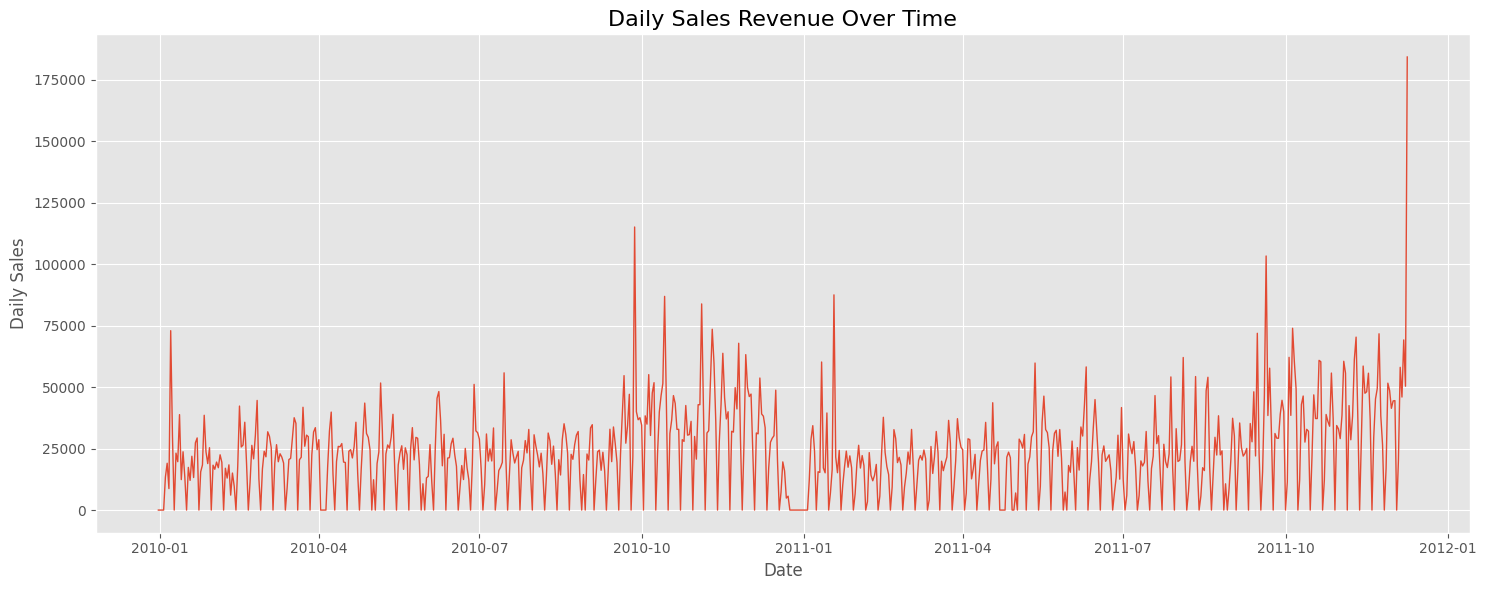

In [17]:
# ==========================================
# Daily Sales Trend
# ==========================================

plt.figure(figsize=(15, 6))

plt.plot(
    forecast_df["Date"],
    forecast_df["DailySales"],
    linewidth=1
)

plt.title("Daily Sales Revenue Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Daily Sales")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "daily_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
# ==========================================
# Forecast Dataset Summary
# ==========================================

summary = pd.DataFrame({
    "Metric": [
        "Start Date",
        "End Date",
        "Original Days",
        "Final Days",
        "Training Samples",
        "Testing Samples",
        "Forecast Features"
    ],
    "Value": [
        str(forecast_df["Date"].min().date()),
        str(forecast_df["Date"].max().date()),
        len(daily_sales),
        len(forecast_df),
        len(train_sales),
        len(test_sales),
        forecast_df.shape[1] - 2
    ]
})

display(summary)

summary.to_csv(
    REPORTS_DIR / "forecasting_dataset_summary.csv",
    index=False
)

print("\nForecasting summary saved successfully.")

,Metric,Value
0,Start Date,2009-12-31
1,End Date,2011-12-09
2,Original Days,739
3,Final Days,709
4,Training Samples,567
5,Testing Samples,142
6,Forecast Features,23



Forecasting summary saved successfully.


In [19]:
# ==========================================
# Notebook Completion Summary
# ==========================================

print("=" * 70)
print("RetailPulse - Notebook 04 Completed Successfully")
print("=" * 70)

print("\nGenerated Files")

print(f"✓ {PROCESSED_DATA_DIR / 'daily_sales.csv'}")
print(f"✓ {PROCESSED_DATA_DIR / 'daily_sales_features.csv'}")
print(f"✓ {PROCESSED_DATA_DIR / 'train_sales.csv'}")
print(f"✓ {PROCESSED_DATA_DIR / 'test_sales.csv'}")

print(f"\n✓ {REPORTS_DIR / 'forecasting_dataset_summary.csv'}")
print(f"✓ {FIGURES_DIR / 'daily_sales_trend.png'}")

print("\nNotebook 05 Ready")
print("Sales Forecasting Model Development")
print("=" * 70)

RetailPulse - Notebook 04 Completed Successfully

Generated Files
✓ c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\data\processed\daily_sales.csv
✓ c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\data\processed\daily_sales_features.csv
✓ c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\data\processed\train_sales.csv
✓ c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\data\processed\test_sales.csv

✓ c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports\forecasting_dataset_summary.csv
✓ c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports\figures\daily_sales_trend.png

Notebook 05 Ready
Sales Forecasting Model Development
